# Part II - Ford GoBike System Usage & Rider Insights
## Explanatory Data Analysis
**by Abdulmalk Alnajem**

## Investigation Overview

In this investigation, the primary objective is to communicate the key factors influencing bike trip durations and to highlight user behavior patterns across different days and times. 

### Key Executive Summary:
1. **Trip Duration Profile:** The vast majority of rides are short, single-purpose trips, peaking sharply between 8 and 12 minutes.
2. **Weekly & Hourly Demand Spikes:** Weekday usage is heavily driven by standard commuting rush hours (8:00 AM and 5:00 PM), whereas weekend usage is evenly distributed during midday hours (11:00 AM to 4:00 PM).
3. **User Demographic Behaviors:** Subscribers (commuters) take frequent, short trips, while casual Customers and Female riders log noticeably longer average trip durations.

## Dataset Overview

The dataset consists of **174,760 individual ride records** from the **Ford GoBike** bike-sharing system in the San Francisco Bay area during **February 2019** (after data cleaning and outlier filtering). 

Key features analyzed include:
- **Trip Metrics:** Trip duration in minutes (`duration_min`).
- **Temporal Attributes:** Hour of the day (`start_hour`) and day of the week (`start_day`).
- **User Demographics:** User classification (`user_type`: Subscriber vs. Customer), gender (`member_gender`), and age (`member_age`).

The explanatory visualizations that follow will demonstrate how trip durations and usage volume dynamically change across these user types and temporal segments.

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [2]:
# load in the dataset into a pandas dataframe
df = pd.read_csv('201902-fordgobike-tripdata.csv')
df_clean = df.copy()

# Cleaning steps
df_clean.dropna(
    subset=[
        'member_birth_year',
        'member_gender',
        'start_station_name',
        'end_station_name',
    ],
    inplace=True,
)
df_clean['start_time'] = pd.to_datetime(df_clean['start_time'])
df_clean['duration_min'] = df_clean['duration_sec'] / 60.0
df_clean['member_age'] = 2019 - df_clean['member_birth_year'].astype(int)
df_clean = df_clean[df_clean['member_age'] <= 80]

df_clean['start_hour'] = df_clean['start_time'].dt.hour
df_clean['start_day'] = df_clean['start_time'].dt.day_name()
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday',
]
df_clean['start_day'] = pd.Categorical(
    df_clean['start_day'], categories=day_order, ordered=True
)

### Distribution of Trip Durations

**Observation:**
The trip duration distribution is heavily right-skewed when plotted on a linear scale. Applying a logarithmic transformation reveals a unimodal distribution with a sharp peak centered between **8 and 12 minutes**. This indicates that the vast majority of bike-share trips are short, single-purpose urban commutes.

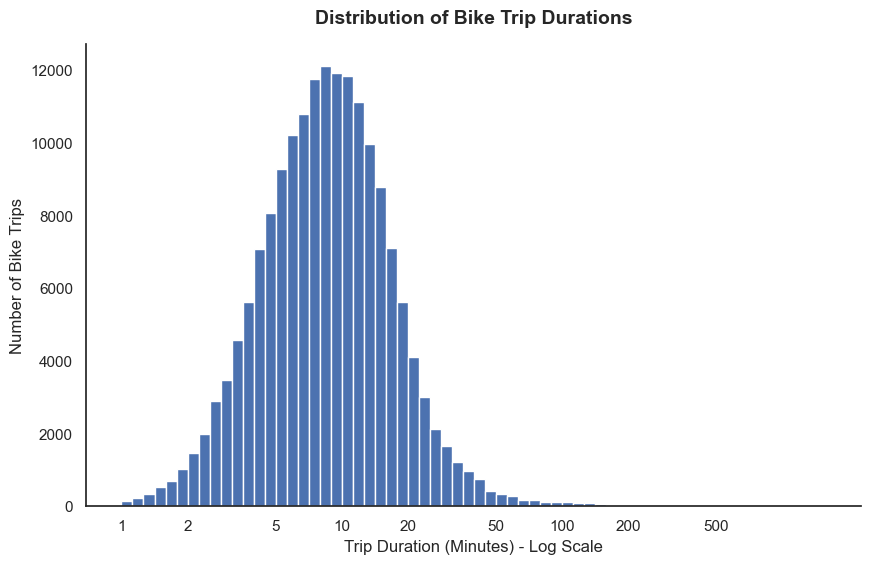

In [3]:
# Set figure size
plt.figure(figsize=[10, 6])

# Set a clean white style without background gridlines
sns.set_theme(style='white')

# Define logarithmic bins for trip duration
bins = 10 ** np.arange(0, np.log10(df_clean['duration_min'].max()) + 0.1, 0.05)

# Plot histogram with log scale
plt.hist(data=df_clean, x='duration_min', bins=bins, color=sns.color_palette()[0])

# Apply log scale to X-axis
plt.xscale('log')

# Custom tick labels for readability on log scale
plt.xticks(
    [1, 2, 5, 10, 20, 50, 100, 200, 500],
    ['1', '2', '5', '10', '20', '50', '100', '200', '500'],
)

# Set polished labels and title
plt.title(
    'Distribution of Bike Trip Durations',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Trip Duration (Minutes) - Log Scale', fontsize=12)
plt.ylabel('Number of Bike Trips', fontsize=12)

# Remove top and right spines for a modern, minimal look
sns.despine()

# Display plot
plt.show()

### Weekly & Hourly Trip Density Patterns

**Observation:**
During weekdays (Monday to Friday), bike usage displays a strong bimodal commute pattern with sharp usage peaks at **8:00 AM** and **5:00 PM**. In contrast, weekend usage shifts to a smooth, continuous distribution centered around midday hours (**11:00 AM to 4:00 PM**), highlighting a transition from daily work commutes to leisure riding.

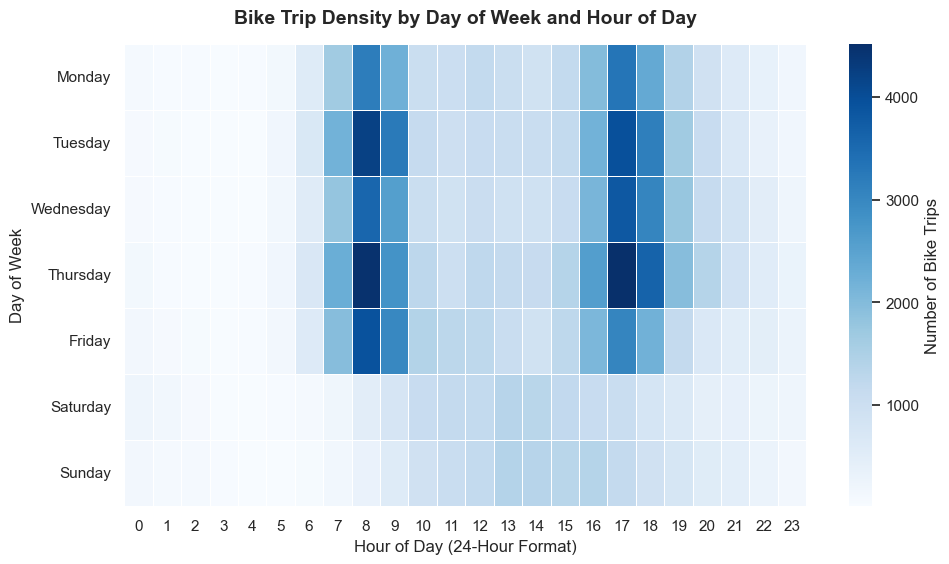

In [4]:
# Set figure size
plt.figure(figsize=[11, 6])

# Set a clean white style without background gridlines
sns.set_theme(style='white')

# Group data by day of the week and start hour to count trip density
counts = (
    df_clean.groupby(['start_day', 'start_hour'], observed=False)
    .size()
    .unstack()
)

# Plot heatmap showing trip density across hours and days
sns.heatmap(
    counts,
    cmap='Blues',
    cbar_kws={'label': 'Number of Bike Trips'},
    linewidths=0.5,
)

# Set polished title and axis labels
plt.title(
    'Bike Trip Density by Day of Week and Hour of Day',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Hour of Day (24-Hour Format)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)

# Display plot
plt.show()

### Mean Trip Duration Across Days of the Week by Gender

**Observation:**
Female and Other gender riders consistently record longer average trip durations compared to Male riders across all days of the week. Additionally, all gender groups experience a clear increase in average trip duration during weekends (Saturday and Sunday), reflecting more relaxed, leisure-oriented riding habits regardless of demographic background.

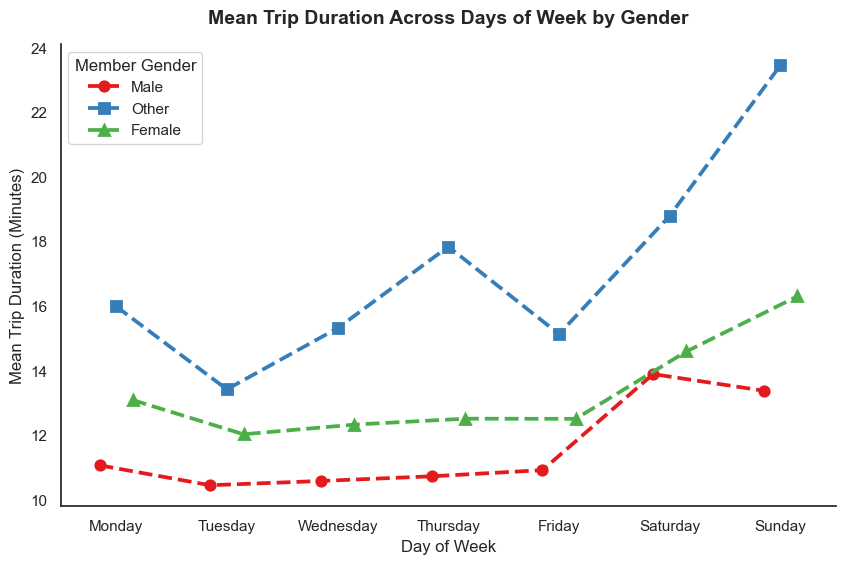

In [5]:
# Set figure size
plt.figure(figsize=[10, 6])

# Set a clean white style without background gridlines
sns.set_theme(style='white')

# Plot point plot showing mean trip duration across days for each gender
sns.pointplot(
    data=df_clean,
    x='start_day',
    y='duration_min',
    hue='member_gender',
    dodge=0.3,
    linestyles='--',
    markers=['o', 's', '^'],
    errorbar=None,
    palette='Set1',
)

# Set polished title, legend, and axis labels
plt.title(
    'Mean Trip Duration Across Days of Week by Gender',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Mean Trip Duration (Minutes)', fontsize=12)
plt.legend(title='Member Gender', loc='upper left')

# Remove top and right spines
sns.despine()

# Display plot
plt.show()